# Connecting to the database

In [1]:
import psycopg2
import pandas as pd

In [2]:
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group15',
    'password': 'blockd_2024group15_73'
}

In [3]:
conn_psycopg2 = psycopg2.connect(**db_params)
cursor = conn_psycopg2.cursor()

# Displaying the preprocessed data

In [4]:
# Execute SQL query to fetch distinct category types
query = '''
    SELECT * 
    FROM group15_warehouse.new_accidents_preprocessed
'''

cursor.execute(query)

# Fetch all rows
new_accident_preprocessed_rows = cursor.fetchall()

# Fetch column names
column_names = [desc[0] for desc in cursor.description]

# Convert the fetched data into a pandas DataFrame
new_accidents_preprocessed = pd.DataFrame(new_accident_preprocessed_rows, columns=column_names)

display(new_accidents_preprocessed)

,Year,Accident severity,Town,First mode of transport,Second mode of transport,Area type,Light condition,Road location,Road condition,Road surface,Road situation,Speed limit,Street,Weather,Accidents
0,2017,Fatal,Breda,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Bavel,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Bavel,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6897,2023,Fatal,Breda,Car,Moped,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Terheijdenseweg,Dry,1
6898,2023,Fatal,Breda,Car,Car,Urban area,Darkness,Intersection,Dry,Asphalt (other),Intersection - 4 arms,70 km/h,Rijsbergseweg,Dry,1
6899,2023,Fatal,Breda,Other,Other,Rural area,Daylight,Road section,Wet/damp,Porous asphalt,Straight road,100 km/h,RYKSWG,Dry,1
6900,2023,Fatal,Prinsenbeek,Car,Car,Rural area,Darkness,Road section,Dry,Porous asphalt,Straight road,130 km/h,RYKSWG,Dry,1


<Axes: >

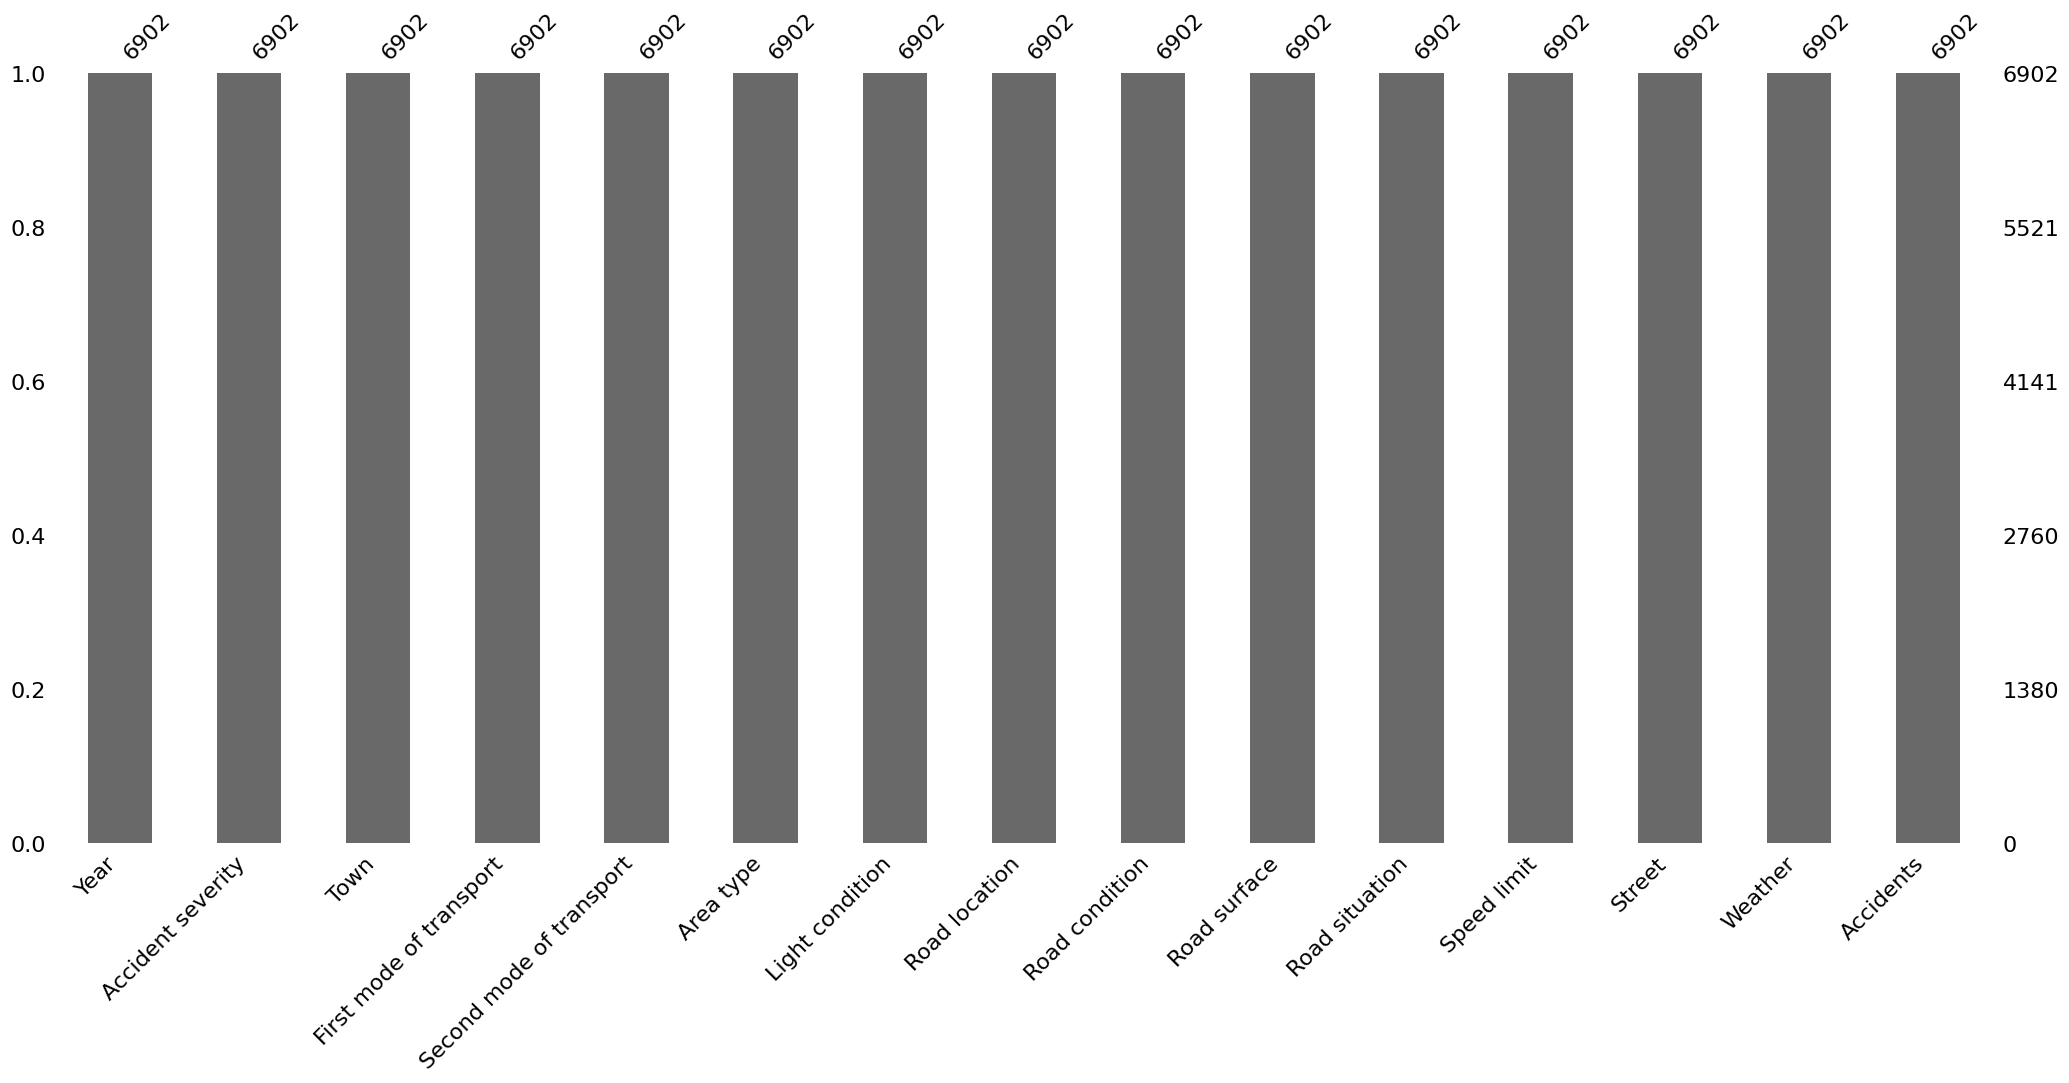

In [5]:
import psycopg2
import pandas as pd
import missingno as msno

# Visualize missing values using missingno
msno.bar(new_accidents_preprocessed)

In [6]:
# Print details of the dataset
print("Data Types:")
print(new_accidents_preprocessed.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6902 entries, 0 to 6901
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      6902 non-null   int64 
 1   Accident severity         6902 non-null   object
 2   Town                      6902 non-null   object
 3   First mode of transport   6902 non-null   object
 4   Second mode of transport  6902 non-null   object
 5   Area type                 6902 non-null   object
 6   Light condition           6902 non-null   object
 7   Road location             6902 non-null   object
 8   Road condition            6902 non-null   object
 9   Road surface              6902 non-null   object
 10  Road situation            6902 non-null   object
 11  Speed limit               6902 non-null   object
 12  Street                    6902 non-null   object
 13  Weather                   6902 non-null   object
 14  Accidents   

In [7]:
# Get value counts for each column
value_counts_per_column = {col: new_accidents_preprocessed[col].value_counts() for col in new_accidents_preprocessed.columns}

# Display the value counts for each column
for column, counts in value_counts_per_column.items():
    print(f"Value counts for column '{column}':")
    print(counts)
    print()

Value counts for column 'Year':
Year
2017    1274
2018    1224
2019    1181
2022    1146
2021    1084
2020     985
2023       8
Name: count, dtype: int64

Value counts for column 'Accident severity':
Accident severity
Material Damage Only    5916
Injured                  936
Fatal                     50
Name: count, dtype: int64

Value counts for column 'Town':
Town
Breda          5935
Prinsenbeek     416
Bavel           296
Teteringen      139
Ulvenhout       113
Galder            2
Etten-leur        1
Name: count, dtype: int64

Value counts for column 'First mode of transport':
First mode of transport
Car             4350
Other            958
Delivery van     496
Moped            362
Lorry            240
Bicycle          181
Light-moped      166
Motorcycle       106
Bus               37
Pedestrian         6
Name: count, dtype: int64

Value counts for column 'Second mode of transport':
Second mode of transport
Other           2762
Car             2463
Bicycle          688
Delivery van

# Feature engineering

In [8]:
import pandas as pd

#  Define the updated mapping dictionary
speed_to_road_type = {
    '130 km/h': 'Highway',
    '120 km/h': 'Expressway',
    '100 km/h': 'Rural Highway',
    '90 km/h': 'Major Rural Road',
    '80 km/h': 'Secondary Rural Road',
    '70 km/h': 'Minor Rural Road',
    '50 km/h': 'Urban Road',
    '30 km/h': 'Town Center Road',
    '60 km/h': 'Build-up Road',
    '15 km/h': 'Residential Road',
    'Footpace / homezone': 'Honezone Road',
    'Unknown': 'Unknown'
}

#  Create the new column 'Road Type' based on 'Speed limit'
new_accidents_preprocessed['Road type'] = new_accidents_preprocessed['Speed limit'].map(speed_to_road_type)

# Check the distribution of the new column
print(new_accidents_preprocessed['Road type'].value_counts())

# Display the first few rows to verify the changes
display(new_accidents_preprocessed.head())

Road type
Urban Road              2762
Unknown                 1103
Town Center Road        1058
Highway                  632
Minor Rural Road         535
Rural Highway            359
Expressway               166
Build-up Road            158
Secondary Rural Road      70
Residential Road          31
Major Rural Road          22
Honezone Road              6
Name: count, dtype: int64


,Year,Accident severity,Town,First mode of transport,Second mode of transport,Area type,Light condition,Road location,Road condition,Road surface,Road situation,Speed limit,Street,Weather,Accidents,Road type
0,2017,Fatal,Breda,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1,Town Center Road
1,2017,Fatal,Breda,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1,Urban Road
2,2017,Fatal,Breda,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1,Urban Road
3,2017,Injured,Bavel,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1,Expressway
4,2017,Injured,Bavel,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1,Highway


# Advanced preprocessing steps before modelling

In [9]:
# Label encode categorical variables
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Accident severity', 'Town', 'First mode of transport', 'Second mode of transport',
                    'Area type', 'Light condition', 'Road location', 'Road condition', 'Road surface', 'Road situation', 'Speed limit', 'Street', 'Weather', 'Road type']

label_encoders = {}
for column in categorical_cols:
    le = LabelEncoder()
    new_accidents_preprocessed[column] = le.fit_transform(new_accidents_preprocessed[column])
    label_encoders[column] = le  # Store the label encoder for inverse transformation if needed

In [10]:
# Check the resulting DataFrame
display(new_accidents_preprocessed.head())

,Year,Accident severity,Town,First mode of transport,Second mode of transport,Area type,Light condition,Road location,Road condition,Road surface,Road situation,Speed limit,Street,Weather,Accidents,Road type
0,2017,0,1,2,9,2,0,0,3,1,0,4,751,3,1,9
1,2017,0,1,5,8,2,1,0,3,1,2,5,451,0,1,11
2,2017,0,1,5,8,2,1,1,0,0,4,5,8,0,1,11
3,2017,1,0,2,5,0,0,1,3,0,0,1,337,0,1,1
4,2017,1,0,2,8,0,0,1,3,3,4,2,615,3,1,2


# Scaling numerical variables

In [11]:
from sklearn.preprocessing import StandardScaler

# Specify numerical features
numerical_cols = ['Year', 'Accidents']

# Initialize StandardScaler for numerical data
scaler = StandardScaler()

# Scale numerical data
new_accidents_preprocessed[numerical_cols] = scaler.fit_transform(new_accidents_preprocessed[numerical_cols])

# Split data into training and testing sets

In [12]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = new_accidents_preprocessed.drop(columns=['Accident severity']) 
y = new_accidents_preprocessed['Accident severity']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.3, 
                                                    random_state=42,
                                                    stratify=y)

In [13]:
# Check for NaN values in features and target
print("\nMissing values in features and target:")
print(X.isnull().sum())
print(y.isnull().sum())


Missing values in features and target:
Year                        0
Town                        0
First mode of transport     0
Second mode of transport    0
Area type                   0
Light condition             0
Road location               0
Road condition              0
Road surface                0
Road situation              0
Speed limit                 0
Street                      0
Weather                     0
Accidents                   0
Road type                   0
dtype: int64
0


# Modelling

## Iteration 1

### Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
log_reg = LogisticRegression(max_iter=10000, random_state=42)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Model:")
print(classification_report(y_test, y_pred_log_reg, zero_division=1))
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Model:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00        15
           1       1.00      0.00      0.00       281
           2       0.86      1.00      0.92      1775

    accuracy                           0.86      2071
   macro avg       0.95      0.33      0.31      2071
weighted avg       0.88      0.86      0.79      2071

[[   0    0   15]
 [   0    0  281]
 [   0    0 1775]]


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Initialize the model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Model:")
print(classification_report(y_test, y_pred_rf, zero_division=1))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.31      0.09      0.13       281
           2       0.86      0.97      0.91      1775

    accuracy                           0.84      2071
   macro avg       0.39      0.35      0.35      2071
weighted avg       0.78      0.84      0.80      2071

[[   0    1   14]
 [   1   24  256]
 [   0   52 1723]]


In [16]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the model
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_clf.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_clf.predict(X_test)

# Evaluate the model
print("Gradient Boosting Classifier Model:")
print(classification_report(y_test, y_pred_gb, zero_division=1))
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Classifier Model:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33        15
           1       0.57      0.09      0.15       281
           2       0.87      0.99      0.93      1775

    accuracy                           0.86      2071
   macro avg       0.81      0.43      0.47      2071
weighted avg       0.83      0.86      0.82      2071

[[   3    1   11]
 [   0   24  257]
 [   0   17 1758]]


## Iteration 2: Fixing class imbalance by adding class_weight='balanced'

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
log_reg = LogisticRegression(max_iter=100000, random_state=42, class_weight='balanced')

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Model:")
print(classification_report(y_test, y_pred_log_reg, zero_division=1))
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.02      0.53      0.04        15
           1       0.21      0.58      0.31       281
           2       0.94      0.48      0.63      1775

    accuracy                           0.49      2071
   macro avg       0.39      0.53      0.33      2071
weighted avg       0.83      0.49      0.58      2071

[[  8   5   2]
 [ 64 162  55]
 [334 595 846]]


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Initialize the model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Model:")
print(classification_report(y_test, y_pred_rf, zero_division=1))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.23      0.05      0.08       281
           2       0.86      0.98      0.91      1775

    accuracy                           0.84      2071
   macro avg       0.36      0.34      0.33      2071
weighted avg       0.77      0.84      0.79      2071

[[   0    0   15]
 [   1   13  267]
 [   1   43 1731]]


In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Initialize the model
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_clf.fit(X_train, y_train, sample_weight=sample_weights)

# Make predictions
y_pred_gb = gb_clf.predict(X_test)

print("Gradient Boosting Classifier Model:")
print(classification_report(y_test, y_pred_gb, zero_division=1))
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Classifier Model:
              precision    recall  f1-score   support

           0       0.04      0.27      0.06        15
           1       0.27      0.61      0.37       281
           2       0.93      0.69      0.79      1775

    accuracy                           0.68      2071
   macro avg       0.41      0.52      0.41      2071
weighted avg       0.84      0.68      0.73      2071

[[   4    7    4]
 [  24  172   85]
 [  83  468 1224]]


## Iteration 3: Fixing class imbalance using SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [21]:
# Initialize the Logistic Regression model with SMOTE
log_reg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')

# Train the model
log_reg.fit(X_train_res, y_train_res)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)

print("Logistic Regression Model with SMOTE:")
print(classification_report(y_test, y_pred_log_reg, zero_division=1))
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Model with SMOTE:
              precision    recall  f1-score   support

           0       0.02      0.33      0.04        15
           1       0.22      0.46      0.29       281
           2       0.90      0.64      0.75      1775

    accuracy                           0.61      2071
   macro avg       0.38      0.48      0.36      2071
weighted avg       0.80      0.61      0.68      2071

[[   5    5    5]
 [  35  129  117]
 [ 173  463 1139]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# Initialize the Random Forest Classifier with SMOTE
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_res, y_train_res)
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Classifier Model with SMOTE:")
print(classification_report(y_test, y_pred_rf, zero_division=1))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Model with SMOTE:
              precision    recall  f1-score   support

           0       0.18      0.13      0.15        15
           1       0.23      0.21      0.22       281
           2       0.87      0.89      0.88      1775

    accuracy                           0.79      2071
   macro avg       0.43      0.41      0.42      2071
weighted avg       0.78      0.79      0.79      2071

[[   2    3   10]
 [   2   59  220]
 [   7  190 1578]]


In [25]:
# Initialize the Gradient Boosting Classifier with SMOTE
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train_res, y_train_res)
y_pred_gb = gb_clf.predict(X_test)

print("Gradient Boosting Classifier Model with SMOTE:")
print(classification_report(y_test, y_pred_gb, zero_division=1))
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Classifier Model with SMOTE:
              precision    recall  f1-score   support

           0       0.06      0.20      0.10        15
           1       0.33      0.25      0.29       281
           2       0.89      0.91      0.90      1775

    accuracy                           0.81      2071
   macro avg       0.43      0.45      0.43      2071
weighted avg       0.81      0.81      0.81      2071

[[   3    3    9]
 [  16   70  195]
 [  29  136 1610]]


# Iteration 4: Model Hyper-tuning

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Initialize Logistic Regression classifier
log_reg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')

# Instantiate GridSearchCV
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', verbose=1)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Logistic Regression:")
print(grid_search.best_params_)
print("Best cross-validation accuracy score: {:.2f}".format(grid_search.best_score_))

# Make predictions using the best model
y_pred_log_reg = grid_search.predict(X_test)

# Evaluate the model
print("Logistic Regression Model after GridSearchCV:")
print(classification_report(y_test, y_pred_log_reg))
print(confusion_matrix(y_test, y_pred_log_reg))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 

KeyboardInterrupt: 

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Instantiate RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Instantiate GridSearchCV
grid_search_rf = GridSearchCV(rf_clf, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the grid search
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Random Forest Classifier:")
print(grid_search_rf.best_params_)
print("Best cross-validation accuracy score: {:.2f}".format(grid_search_rf.best_score_))

# Make predictions using the best model
y_pred_rf = grid_search_rf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Model after GridSearchCV:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters found for Random Forest Classifier:
{'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy score: 0.85
Random Forest Classifier Model after GridSearchCV:
              precision    recall  f1-score   support

           0       0.33      0.07      0.11        15
           1       0.25      0.07      0.11       281
           2       0.86      0.97      0.91      1775

    accuracy                           0.84      2071
   macro avg       0.48      0.37      0.38      2071
weighted avg       0.78      0.84      0.80      2071

[[   1    1   13]
 [   1   19  261]
 [   1   56 1718]]


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Instantiate RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Instantiate GridSearchCV
grid_search_rf = GridSearchCV(rf_clf, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the grid search
grid_search_rf.fit(X_train_res, y_train_res)

# Print the best parameters and best score
print("Best parameters found for Random Forest Classifier:")
print(grid_search_rf.best_params_)
print("Best cross-validation accuracy score: {:.2f}".format(grid_search_rf.best_score_))

# Make predictions using the best model
y_pred_rf = grid_search_rf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Model after GridSearchCV:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters found for Random Forest Classifier:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation accuracy score: 0.92
Random Forest Classifier Model after GridSearchCV:
              precision    recall  f1-score   support

           0       0.22      0.13      0.17        15
           1       0.25      0.20      0.22       281
           2       0.87      0.91      0.89      1775

    accuracy                           0.80      2071
   macro avg       0.45      0.41      0.42      2071
weighted avg       0.78      0.80      0.79      2071

[[   2    4    9]
 [   3   55  223]
 [   4  164 1607]]


In [29]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

# Define parameter distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': stats.randint(2, 20),
    'min_samples_leaf': stats.randint(1, 20)
}

# Instantiate GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(random_state=42)

# Instantiate RandomizedSearchCV
random_search_gb = RandomizedSearchCV(gb_clf, param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', random_state=42, verbose=1, n_jobs=-1)

# Fit the random search
random_search_gb.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Gradient Boosting Classifier:")
print(random_search_gb.best_params_)
print("Best cross-validation accuracy score: {:.2f}".format(random_search_gb.best_score_))

# Make predictions using the best model
y_pred_gb = random_search_gb.predict(X_test)

# Evaluate the model
print("Gradient Boosting Classifier Model after RandomizedSearchCV:")
print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found for Gradient Boosting Classifier:
{'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 6, 'min_samples_split': 17, 'n_estimators': 50}
Best cross-validation accuracy score: 0.86
Gradient Boosting Classifier Model after RandomizedSearchCV:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.44      0.07      0.12       281
           2       0.87      0.99      0.92      1775

    accuracy                           0.86      2071
   macro avg       0.44      0.35      0.35      2071
weighted avg       0.80      0.86      0.81      2071

[[   0    3   12]
 [   1   20  260]
 [   0   22 1753]]


In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

# Define parameter distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': stats.randint(2, 20),
    'min_samples_leaf': stats.randint(1, 20)
}

# Instantiate GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(random_state=42)

# Instantiate RandomizedSearchCV
random_search_gb = RandomizedSearchCV(gb_clf, param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', random_state=42, verbose=1, n_jobs=-1)

# Fit the random search
random_search_gb.fit(X_train_res, y_train_res)

# Print the best parameters and best score
print("Best parameters found for Gradient Boosting Classifier:")
print(random_search_gb.best_params_)
print("Best cross-validation accuracy score: {:.2f}".format(random_search_gb.best_score_))

# Make predictions using the best model
y_pred_gb = random_search_gb.predict(X_test)

# Evaluate the model
print("Gradient Boosting Classifier Model after RandomizedSearchCV:")
print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found for Gradient Boosting Classifier:
{'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 14, 'min_samples_split': 8, 'n_estimators': 200}
Best cross-validation accuracy score: 0.92
Gradient Boosting Classifier Model after RandomizedSearchCV:
              precision    recall  f1-score   support

           0       0.33      0.20      0.25        15
           1       0.27      0.15      0.20       281
           2       0.87      0.94      0.90      1775

    accuracy                           0.82      2071
   macro avg       0.49      0.43      0.45      2071
weighted avg       0.79      0.82      0.80      2071

[[   3    5    7]
 [   3   43  235]
 [   3  110 1662]]


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


# Define neural network architecture
model = Sequential([
    Dense(256, input_dim=X_train_res.shape[1]),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(len(np.unique(y_train)), activation='softmax')  # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_res, y_train_res, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")

# Make predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Evaluate predictions
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.3824 - loss: 1.5074 - val_accuracy: 0.4872 - val_loss: 1.0018
Epoch 2/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5056 - loss: 1.0083 - val_accuracy: 0.3438 - val_loss: 1.3235
Epoch 3/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5822 - loss: 0.8877 - val_accuracy: 0.5229 - val_loss: 0.9374
Epoch 4/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6036 - loss: 0.8569 - val_accuracy: 0.5703 - val_loss: 0.7685
Epoch 5/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6274 - loss: 0.8301 - val_accuracy: 0.5205 - val_loss: 0.8870
Epoch 6/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6322 - loss: 0.8085 - val_accuracy: 0.4616 - val_loss: 0.9370
Epoch 7/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6308 - loss: 0.8104 - val_accuracy: 0.5456 - val_loss: 0.7771
Epoch 8/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6511 - loss: 0.7814 - val_accuracy: 0.5649 - va

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Define neural network architecture
model = Sequential([
    Dense(512, input_dim=X_train_res.shape[1]),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(len(np.unique(y_train_res)), activation='softmax')  # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")

# Make predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Evaluate predictions
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


389/389 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3675 - loss: 1.5958 - val_accuracy: 0.1994 - val_loss: 1.4570 - learning_rate: 0.0010
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4651 - loss: 1.0661 - val_accuracy: 0.4462 - val_loss: 1.0132 - learning_rate: 0.0010
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5387 - loss: 0.9444 - val_accuracy: 0.5157 - val_loss: 0.8941 - learning_rate: 0.0010
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6076 - loss: 0.8559 - val_accuracy: 0.5302 - val_loss: 0.7610 - learning_rate: 0.0010
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6150 - loss: 0.8325 - val_accuracy: 0.5620 - val_loss: 0.7489 - learning_rate: 0.0010
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6221 - loss: 0.8188 - val_accuracy: 0.4660 - val_loss: 0.9567 - learning_rate: 0.0010
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6327 - loss: 0.8003 - val

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


# Define neural network architecture
model = Sequential([
    Dense(512, kernel_regularizer=l2(0.01), input_dim=X_train_res.shape[1]),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, kernel_regularizer=l2(0.01)),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, kernel_regularizer=l2(0.01)),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, kernel_regularizer=l2(0.01)),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(len(np.unique(y_train_res)), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")

# Make predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Evaluate predictions
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.3513 - loss: 7.2702 - val_accuracy: 0.3583 - val_loss: 4.6744 - learning_rate: 0.0010
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4256 - loss: 4.3275 - val_accuracy: 0.5751 - val_loss: 2.7992 - learning_rate: 0.0010
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4800 - loss: 2.7083 - val_accuracy: 0.3404 - val_loss: 2.1062 - learning_rate: 0.0010
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5267 - loss: 1.8538 - val_accuracy: 0.1072 - val_loss: 2.2199 - learning_rate: 0.0010
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5586 - loss: 1.4316 - val_accuracy: 0.5712 - val_loss: 1.1348 - learning_rate: 0.0010
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5680 - loss: 1.2315 - val_accuracy: 0.2168 - val_loss: 1.6645 - learning_rate: 0.0010
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5753 - loss: 1.1521 - val

2024-06-21 08:28:02.596432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


NameError: name 'X_train_res' is not defined